In [4]:
import numpy
import sklearn

print(numpy.__version__)
print(sklearn.__version__)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

# Data handling
import pandas as pd
import numpy as np
#
# ML preprocessing & evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Model
import sklearn
from sklearn.ensemble import RandomForestClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

p🟡 ML PIPELINE VIEW:

This stage prepares all tools needed for the ML system:

* Data → pandas
* Model → sklearn
* Balancing → SMOTE
* Evaluation → metrics
* Saving → joblib

In [97]:
# =========================
# 2. LOAD DATA
# =========================

df = pd.read_csv("depression.csv")

In [98]:
# =========================
# 3. CLEAN COLUMN NAMES
# =========================

# Remove hidden spaces in column names
df.columns = df.columns.str.strip()

🟡 WHY THIS MATTERS:

* Prevents errors like " Sleep " vs "Sleep"
* Ensures model reads correct features

In [99]:
# =========================
# 4. CLEAN TARGET COLUMN
# =========================

# Normalize text (case + spaces)
df["Depression State"] = (
    df["Depression State"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Fix corrupted dataset labels
df["Depression State"] = df["Depression State"].replace({
    "nan": np.nan,
    "none": np.nan,
    "": np.nan,
    "2\tno depression": "no depression",
    "5\tno depression": "no depression",
    "\tno depression": "no depression",
    "\tmoderate": "moderate",
    "\tmild": "mild",
    "\tsevere": "severe",
})

# Remove invalid labels
df = df.dropna(subset=["Depression State"])

🟡 ML PIPELINE VIEW:

This is Label Engineering + Data Cleaning

We are:

* Fixing corrupted labels
* Removing noise
* Standardizing classes

In [100]:
# =========================
# 5. CLEAN FEATURES
# =========================

feature_cols = [
    "Sleep", "Appetite", "Interest", "Fatigue",
    "Worthlessness", "Concentration", "Agitation",
    "Suicidal Ideation", "Sleep Disturbance",
    "Aggression", "Panic Attacks", "Hopelessness",
    "Restlessness", "Low Energy"
]

# Fill missing values with median (robust to outliers)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

🟡 WHY MEDIAN?

* Depression data has outliers
* Median is stable vs mean

In [101]:
# =========================
# 6. SPLIT DATA
# =========================

X = df[feature_cols]          # Inputs (symptoms)
y = df["Depression State"]     # Target (labels)

🟡 ML PIPELINE VIEW:

Defines:

* X = symptoms
* y = diagnosis

In [102]:
# =========================
# 7. LABEL ENCODING
# =========================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Show mapping
print("\nClass mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")


Class mapping:
0 -> mild
1 -> moderate
2 -> no depression
3 -> severe


🟡 WHY THIS IS REQUIRED:

ML models cannot understand text:

In [103]:
# =========================
# 8. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # keeps class balance
)

🟡 WHY STRATIFY?

Ensures:

* Same class distribution in train/test

In [104]:
# =========================
# 9. SMOTE (BALANCING)
# =========================

smote = SMOTE(random_state=42, k_neighbors=2)

🟡 PURPOSE:

* Fix imbalance between classes
* Prevent model bias toward “majority class”

In [105]:
# =========================
# 10. SCALING
# =========================

scaler = StandardScaler()

🟡 WHY SCALING?

* Normalizes feature ranges
* Improves model stability

In [106]:
# =========================
# 11. MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

🟡 WHY RANDOM FOREST?

* Works well on small datasets
* Handles non-linear relationships
* Robust to noise

In [107]:
# =========================
# 12. PIPELINE
# =========================

pipeline = ImbPipeline(steps=[
    ("scaler", scaler),
    ("smote", smote),
    ("model", model)
])

🟡 ML PIPELINE FLOW:

Raw Data

   ↓

Scaling

   ↓

SMOTE (balance classes)

   ↓

Random Forest Model

   ↓

Prediction

In [108]:
# =========================
# 13. CROSS VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("\nCV Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


CV Scores: [0.46735127 0.38542721 0.44463382 0.46228676 0.47658331]
Mean CV F1: 0.44725647078553965


🟡 WHY CV?

* Tests model stability
* Prevents overfitting

In [109]:
# =========================
# 14. TRAIN MODEL
# =========================

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(k_neighbors=2, random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=300, random_state=42))])

🟡 WHAT HAPPENS HERE:

Entire pipeline runs: Scale → SMOTE → Train Model

In [110]:
# =========================
# 15. PREDICTIONS
# =========================

y_pred = pipeline.predict(X_test)

In [111]:
# =========================
# 16. EVALUATION REPORT
# =========================

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


CLASSIFICATION REPORT:

               precision    recall  f1-score   support

         mild       0.41      0.42      0.42        26
     moderate       0.42      0.21      0.28        24
no depression       0.79      0.63      0.70        35
       severe       0.29      0.52      0.38        23

     accuracy                           0.46       108
    macro avg       0.48      0.45      0.44       108
 weighted avg       0.51      0.46      0.47       108



🟡 WHAT YOU SEE:

* Precision → correctness
* Recall → coverage
* F1-score → balance

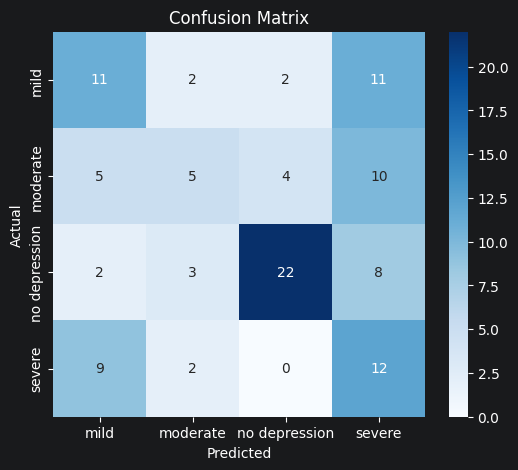

In [94]:
# =========================
# 17. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🟡 WHAT THIS SHOWS:

* Where model is confusing classes
* Example: mild ↔ moderate

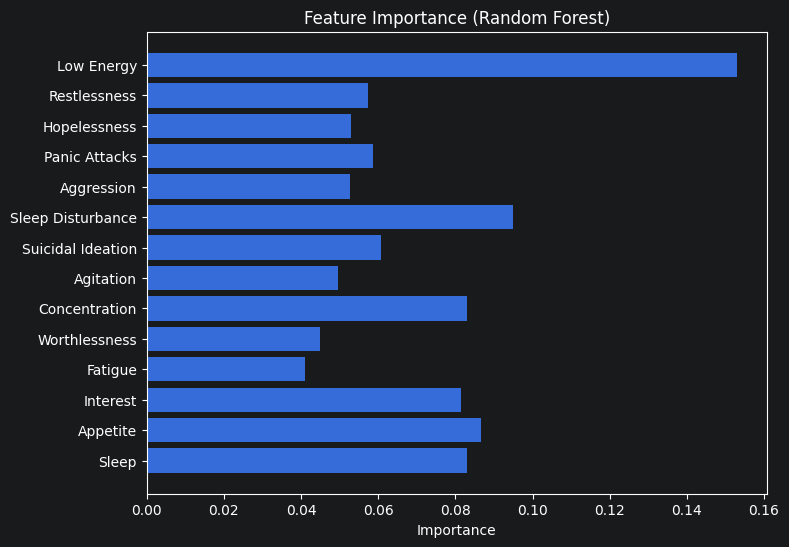

In [95]:
# =========================
# 18. FEATURE IMPORTANCE
# =========================

importances = pipeline.named_steps["model"].feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(feature_cols, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

🟡 MEANING:

Shows:

* which symptoms matter most
* e.g. Low Energy usually high impact

In [ ]:
#Reliability Diagram



In [77]:
# =========================
# 19. SAVE MODEL
# =========================

model_info = {
    "model": model,
    "sklearn_version": sklearn.__version__
}

joblib.dump(model_info, "model_bundle.pkl")
joblib.dump(pipeline, "depression_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("\nModel saved successfully!")


Model saved successfully!


You can now:

* deploy API
* build mobile app
* use in production systems

1. Load Data
2. Clean Data
3. Clean Labels
4. Handle Missing Values
5. Encode Labels
6. Split Data
7. Balance Data (SMOTE)
8. Scale Features
9. Train Model
10. Cross Validate
11. Predict
12. Evaluate
13. Visualize
14. Save Model